<a href="https://colab.research.google.com/github/imran-mid/ai-voice-disorder-prediction/blob/main/ML4Health_Baselines_using_v3_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# CELL 1: Mount Drive, imports
# ==============================================================================
# !pip install pyarrow

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import pickle
import warnings
from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

DATA_DIR = '/content/drive/MyDrive/ML 4 Health Project/data'


Mounted at /content/drive


In [ ]:

# ==============================================================================
# CELL 2: Build labels from v3.0.0 diagnosis files (same as CNN notebook)
# ==============================================================================

def load_tsv(filename):
    possible_paths = [
        os.path.join(DATA_DIR, filename),
        os.path.join(DATA_DIR, 'phenotype', filename),
        os.path.join(DATA_DIR, os.path.basename(filename)),
    ]
    for path in possible_paths:
        if os.path.exists(path):
            return pd.read_csv(path, sep='\t')
    print(f"  WARNING: Could not find {filename}")
    return None

voice_disorder_files = [
    'diagnosis/laryngeal_cancer.tsv',
    'diagnosis/benign_lesions.tsv',
    'diagnosis/unilateral_vocal_fold_paralysis.tsv',
    'diagnosis/glottic_insufficiency.tsv',
    'diagnosis/muscle_tension_dysphonia.tsv',
    'diagnosis/laryngeal_dystonia.tsv',
    'diagnosis/precancerous_lesions.tsv',
    'diagnosis/laryngitis.tsv',
    'diagnosis/airway_stenosis.tsv',
]

disorder_pids = set()
for fname in voice_disorder_files:
    df = load_tsv(fname)
    if df is not None and 'participant_id' in df.columns:
        disorder_pids.update(df['participant_id'].unique())

control_df = load_tsv('diagnosis/control.tsv')
control_pids = set()
if control_df is not None and 'participant_id' in control_df.columns:
    control_pids = set(control_df['participant_id'].unique()) - disorder_pids

# Build label map with zero-padded string keys (to match feature file IDs)
participant_label_map = {}
for pid in disorder_pids:
    participant_label_map[str(pid).zfill(6)] = 1
for pid in control_pids:
    participant_label_map[str(pid).zfill(6)] = 0

print(f"Labels built from v3.0.0 diagnosis files:")
print(f"  Voice disorder: {sum(v == 1 for v in participant_label_map.values())}")
print(f"  Control:        {sum(v == 0 for v in participant_label_map.values())}")



Labels built from v3.0.0 diagnosis files:
  Voice disorder: 424
  Control:        146


In [ ]:
# ==============================================================================
# CELL 3: Load static_features.tsv from v3.0.0
# ==============================================================================

sf_path = None
for candidate in [
    os.path.join(DATA_DIR, 'features', 'static_features.tsv'),
    os.path.join(DATA_DIR, 'static_features.tsv'),
]:
    if os.path.exists(candidate):
        sf_path = candidate
        break

if sf_path is None:
    print("ERROR: static_features.tsv not found!")
    print("Download it from PhysioNet v3.0.0 (76.1 MB)")
else:
    print(f"Loading static features from: {sf_path}")
    static_df = pd.read_csv(sf_path, sep='\t')
    print(f"Loaded: {static_df.shape[0]} recordings, {static_df.shape[1]} columns")
    print(f"Unique participants: {static_df['participant_id'].nunique()}")

# Check participant_id format
print(f"\nSample participant IDs: {static_df['participant_id'].unique()[:5]}")


Loading static features from: /content/drive/MyDrive/ML 4 Health Project/data/features/static_features.tsv
Loaded: 32249 recordings, 135 columns
Unique participants: 833

Sample participant IDs: [1573 2475 4119 4946 5009]


In [ ]:

# ==============================================================================
# CELL 4: Filter to labeled participants and prepare features
# ==============================================================================

# Ensure participant_id is string and zero-padded
static_df['participant_id'] = static_df['participant_id'].astype(str).str.zfill(6)

# Filter to labeled participants only
static_labeled = static_df[static_df['participant_id'].isin(participant_label_map)].copy()
static_labeled['label'] = static_labeled['participant_id'].map(participant_label_map)

print(f"Recordings with labels: {len(static_labeled)} ({static_labeled['participant_id'].nunique()} participants)")
print(f"Label distribution:")
print(static_labeled['label'].value_counts())

# Identify feature columns (drop metadata and label)
meta_cols = ['participant_id', 'session_id', 'task_name', 'label']
# Also drop any columns that might be non-numeric or identifiers
feature_cols = [c for c in static_labeled.columns if c not in meta_cols]

# Check for non-numeric columns
non_numeric = []
for col in feature_cols:
    if not pd.api.types.is_numeric_dtype(static_labeled[col]):
        non_numeric.append(col)

if non_numeric:
    print(f"\nDropping non-numeric columns: {non_numeric}")
    feature_cols = [c for c in feature_cols if c not in non_numeric]

print(f"\nFeature columns: {len(feature_cols)}")

# Handle NaNs — same approach as original: drop columns with >50 NaNs, then drop rows
nan_counts = static_labeled[feature_cols].isna().sum()
high_nan_cols = nan_counts[nan_counts > 50].index.tolist()
if high_nan_cols:
    print(f"Dropping {len(high_nan_cols)} columns with >50 NaNs")
    feature_cols = [c for c in feature_cols if c not in high_nan_cols]

static_clean = static_labeled[meta_cols + feature_cols].dropna()
print(f"After cleaning: {len(static_clean)} recordings, {len(feature_cols)} features")
print(f"Unique participants after cleaning: {static_clean['participant_id'].nunique()}")


Recordings with labels: 20181 (570 participants)
Label distribution:
label
1    14964
0     5217
Name: count, dtype: int64

Dropping non-numeric columns: ['transcription']

Feature columns: 131
Dropping 35 columns with >50 NaNs
After cleaning: 20141 recordings, 96 features
Unique participants after cleaning: 570


In [ ]:

# ==============================================================================
# CELL 5: Reconstruct the SAME train/val/test split as CNN
# ==============================================================================
# Uses the exact same random seed and splitting logic as CNN Cell 10

np.random.seed(42)

pid_labels = {}
for pid in static_clean['participant_id'].unique():
    pid_labels[pid] = participant_label_map[pid]

unique_pids = list(pid_labels.keys())
print(f"Unique participants: {len(unique_pids)}")

# Same split logic as CNN notebook
n_test_groups = int(len(unique_pids) * 0.15)
pids_class1 = [pid for pid in unique_pids if pid_labels[pid] == 1]
pids_class0 = [pid for pid in unique_pids if pid_labels[pid] == 0]

n_per_class = n_test_groups // 2
test_pids_1 = list(np.random.choice(pids_class1, n_per_class, replace=False))
test_pids_0 = list(np.random.choice(pids_class0, n_per_class, replace=False))
test_pids = set(test_pids_1 + test_pids_0)
train_val_pids = set(unique_pids) - test_pids

train_val_list = list(train_val_pids)
np.random.shuffle(train_val_list)
tv_class1 = [p for p in train_val_list if pid_labels[p] == 1]
tv_class0 = [p for p in train_val_list if pid_labels[p] == 0]
n_val_per_class = max(1, int(len(train_val_list) * 0.15) // 2)
val_pids = set(tv_class1[:n_val_per_class] + tv_class0[:n_val_per_class])
train_pids = train_val_pids - val_pids

# IMPORTANT: Check that the participant sets match what the CNN used.
# If the set of participants differs slightly (e.g., some participants have
# mel spectrograms but no static features or vice versa), the split won't
# be identical. Print a warning if so.
print(f"\nSplit (by participant):")
print(f"  Train: {len(train_pids)}  Val: {len(val_pids)}  Test: {len(test_pids)}")

# Assign recordings to splits
train_mask = static_clean['participant_id'].isin(train_pids)
val_mask = static_clean['participant_id'].isin(val_pids)
test_mask = static_clean['participant_id'].isin(test_pids)

X_train = static_clean.loc[train_mask, feature_cols].values
y_train = static_clean.loc[train_mask, 'label'].values
groups_train = static_clean.loc[train_mask, 'participant_id'].values

X_val = static_clean.loc[val_mask, feature_cols].values
y_val = static_clean.loc[val_mask, 'label'].values

X_test = static_clean.loc[test_mask, feature_cols].values
y_test = static_clean.loc[test_mask, 'label'].values

print(f"\nSplit (by recording):")
print(f"  Train: {len(X_train)} (disorder: {sum(y_train)}, control: {len(y_train)-sum(y_train)})")
print(f"  Val:   {len(X_val)} (disorder: {sum(y_val)}, control: {len(y_val)-sum(y_val)})")
print(f"  Test:  {len(X_test)} (disorder: {sum(y_test)}, control: {len(y_test)-sum(y_test)})")


Unique participants: 570

Split (by participant):
  Train: 414  Val: 72  Test: 84

Split (by recording):
  Train: 14568 (disorder: 12176, control: 2392)
  Val:   2555 (disorder: 1292, control: 1263)
  Test:  3018 (disorder: 1467, control: 1551)


In [ ]:

# ==============================================================================
# CELL 6: Train Logistic Regression with GroupKFold
# ==============================================================================

print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

# Use GroupKFold for cross-validation (same as original)
# Combine train + val for CV, hold out test
X_trainval = np.concatenate([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])
groups_trainval = np.concatenate([
    groups_train,
    static_clean.loc[val_mask, 'participant_id'].values
])

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=5000, class_weight='balanced'))
])

# Grid search with GroupKFold
param_grid_lr = {'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100]}
gkf = GroupKFold(n_splits=7)

gs_lr = GridSearchCV(
    lr_pipeline, param_grid_lr,
    scoring='f1_weighted', cv=gkf,
    n_jobs=-1, refit=True, return_train_score=True
)
gs_lr.fit(X_trainval, y_trainval, groups=groups_trainval)

# Results
cv_res = pd.DataFrame(gs_lr.cv_results_)
best_idx = gs_lr.best_index_
print(f"Best params: {gs_lr.best_params_}")
print(f"Best CV train F1: {cv_res.loc[best_idx, 'mean_train_score']:.4f}")
print(f"Best CV val F1:   {cv_res.loc[best_idx, 'mean_test_score']:.4f}")

# Test evaluation
y_test_pred_lr = gs_lr.predict(X_test)
lr_test_f1 = f1_score(y_test, y_test_pred_lr, average='weighted')
print(f"Test F1:          {lr_test_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred_lr, target_names=['Control', 'Voice Disorder']))


LOGISTIC REGRESSION
Best params: {'logreg__C': 1}
Best CV train F1: 0.7190
Best CV val F1:   0.6992
Test F1:          0.6694

Classification Report:
                precision    recall  f1-score   support

       Control       0.68      0.67      0.68      1551
Voice Disorder       0.66      0.67      0.66      1467

      accuracy                           0.67      3018
     macro avg       0.67      0.67      0.67      3018
  weighted avg       0.67      0.67      0.67      3018



In [ ]:
# ==============================================================================
# CELL 7: Train Decision Tree with GroupKFold
# ==============================================================================

print("=" * 60)
print("DECISION TREE")
print("=" * 60)

# param_grid_dt = {
#     'max_depth': [3, 5, 10, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 5, 10],
# }
param_grid_dt = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [5, 10, 20],
}

gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid_dt,
    scoring='f1_weighted', cv=gkf,
    n_jobs=-1, refit=True, return_train_score=True
)
gs_dt.fit(X_trainval, y_trainval, groups=groups_trainval)

cv_res_dt = pd.DataFrame(gs_dt.cv_results_)
best_idx_dt = gs_dt.best_index_
print(f"Best params: {gs_dt.best_params_}")
print(f"Best CV train F1: {cv_res_dt.loc[best_idx_dt, 'mean_train_score']:.4f}")
print(f"Best CV val F1:   {cv_res_dt.loc[best_idx_dt, 'mean_test_score']:.4f}")

y_test_pred_dt = gs_dt.predict(X_test)
dt_test_f1 = f1_score(y_test, y_test_pred_dt, average='weighted')
print(f"Test F1:          {dt_test_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred_dt, target_names=['Control', 'Voice Disorder']))


DECISION TREE
Best params: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 5}
Best CV train F1: 0.8390
Best CV val F1:   0.6968
Test F1:          0.6390

Classification Report:
                precision    recall  f1-score   support

       Control       0.69      0.56      0.61      1551
Voice Disorder       0.61      0.73      0.66      1467

      accuracy                           0.64      3018
     macro avg       0.65      0.64      0.64      3018
  weighted avg       0.65      0.64      0.64      3018



In [ ]:
# ==============================================================================
# CELL 8: Train Random Forest with GroupKFold
# ==============================================================================

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)

# param_grid_rf = {
#     'n_estimators': [5, 50, 100],
#     'min_samples_split': [2, 5, 10],
# }
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [5, 10],
}
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid_rf,
    scoring='f1_weighted', cv=gkf,
    n_jobs=-1, refit=True, return_train_score=True
)
gs_rf.fit(X_trainval, y_trainval, groups=groups_trainval)

cv_res_rf = pd.DataFrame(gs_rf.cv_results_)
best_idx_rf = gs_rf.best_index_
print(f"Best params: {gs_rf.best_params_}")
print(f"Best CV train F1: {cv_res_rf.loc[best_idx_rf, 'mean_train_score']:.4f}")
print(f"Best CV val F1:   {cv_res_rf.loc[best_idx_rf, 'mean_test_score']:.4f}")

y_test_pred_rf = gs_rf.predict(X_test)
rf_test_f1 = f1_score(y_test, y_test_pred_rf, average='weighted')
print(f"Test F1:          {rf_test_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred_rf, target_names=['Control', 'Voice Disorder']))


RANDOM FOREST
Best params: {'max_depth': 15, 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best CV train F1: 0.9689
Best CV val F1:   0.7960
Test F1:          0.6337

Classification Report:
                precision    recall  f1-score   support

       Control       0.82      0.42      0.55      1551
Voice Disorder       0.60      0.90      0.72      1467

      accuracy                           0.65      3018
     macro avg       0.71      0.66      0.64      3018
  weighted avg       0.71      0.65      0.63      3018



In [ ]:
# ==============================================================================
# CELL 9: Full comparison table (including CNN result)
# ==============================================================================

# Enter your CNN test F1 from the CNN notebook here:
CNN_TEST_F1 = 0.6698  # <-- update if different

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'CNN (mel spectrogram)',
    ],
    'Features': [
        'Static Acoustic', 'Static Acoustic', 'Static Acoustic', 'Mel Spectrogram'
    ],
    'CV Train F1': [
        cv_res.loc[best_idx, 'mean_train_score'],
        cv_res_dt.loc[best_idx_dt, 'mean_train_score'],
        cv_res_rf.loc[best_idx_rf, 'mean_train_score'],
        0.7355,  # CNN train F1 at best epoch
    ],
    'CV Val F1': [
        cv_res.loc[best_idx, 'mean_test_score'],
        cv_res_dt.loc[best_idx_dt, 'mean_test_score'],
        cv_res_rf.loc[best_idx_rf, 'mean_test_score'],
        0.6847,
    ],
    'Test F1': [
        lr_test_f1, dt_test_f1, rf_test_f1, CNN_TEST_F1
    ],
})

print("\n" + "=" * 80)
print("FULL MODEL COMPARISON — All on Bridge2AI-Voice v3.0.0, same participant split")
print("=" * 80)
print(comparison.to_string(index=False))
print("\nAll models evaluated on the same test set (same participants, same split seed).")



FULL MODEL COMPARISON — All on Bridge2AI-Voice v3.0.0, same participant split
                Model        Features  CV Train F1  CV Val F1  Test F1
  Logistic Regression Static Acoustic     0.719029   0.699207 0.669361
        Decision Tree Static Acoustic     0.839025   0.696845 0.639042
        Random Forest Static Acoustic     0.968911   0.796013 0.633654
CNN (mel spectrogram) Mel Spectrogram     0.735500   0.684700 0.669800

All models evaluated on the same test set (same participants, same split seed).


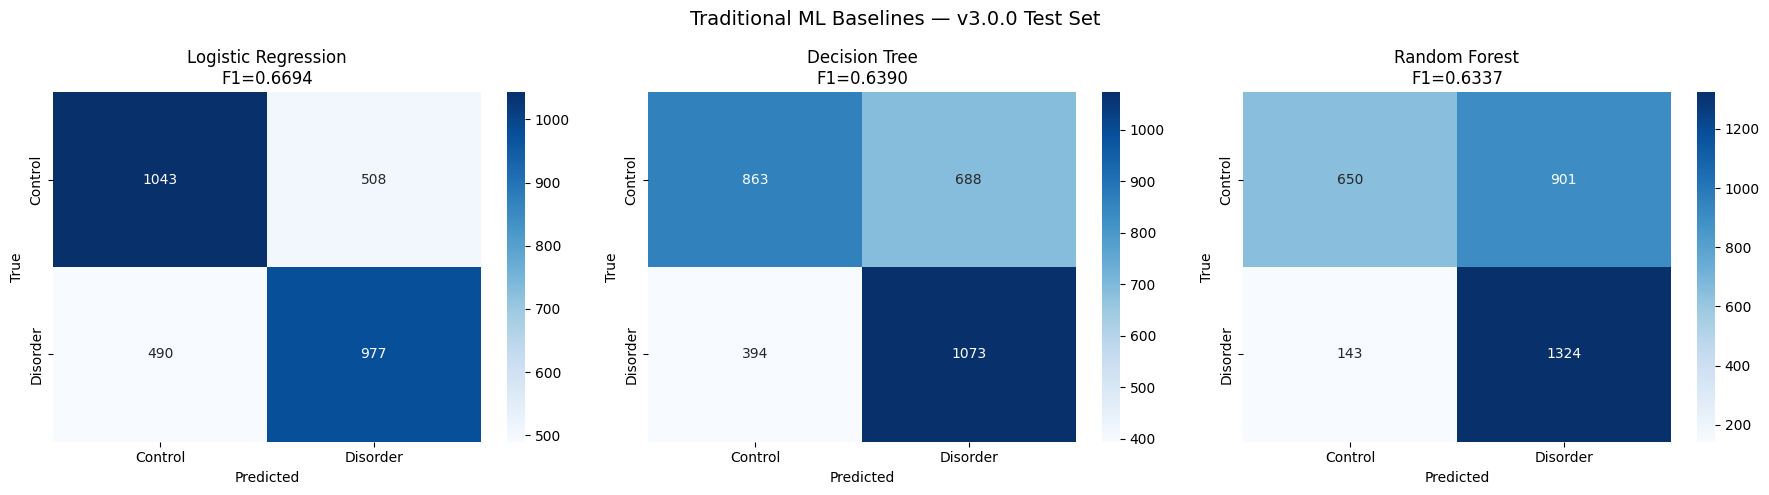

In [ ]:
# ==============================================================================
# CELL 10: Confusion matrices side by side
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = [
    ('Logistic Regression', y_test_pred_lr, lr_test_f1),
    ('Decision Tree', y_test_pred_dt, dt_test_f1),
    ('Random Forest', y_test_pred_rf, rf_test_f1),
]

for ax, (name, preds, f1) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Control', 'Disorder'],
                yticklabels=['Control', 'Disorder'], ax=ax)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')
    ax.set_title(f'{name}\nF1={f1:.4f}')

plt.suptitle('Traditional ML Baselines — v3.0.0 Test Set', fontsize=14)
plt.tight_layout()
plt.show()